# Bacterial Gene Prediction Benchmark Dashboard

Evaluation of Dual-Strand 2nd-Order Hidden Markov Model across 4 bactrial genomes.

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure src modules are resolvable
sys.path.append(os.path.abspath(".."))

from src.data_loader import download_genome_data, parse_genome_and_labels_4state, create_train_test_split
from src.train import train_2nd_order_hmm
from src.hmm_model import HMMGenePredictor2ndOrder
from src.evaluate import (
    extract_predicted_genes, 
    evaluate_gene_boundaries, 
    evaluate_nucleotide_level,
    map_reverse_predictions,
    resolve_strand_overlaps
)
from src.utils import reverse_complement

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig_dpi = 150

In [3]:
def run_benchmark(accession: str, organism_name: str, train_ratio: float = 0.8, min_length: int = 180):
    """
    Downloads, trains, decodes dual-strand Viterbi, and collects quantitative metrics.
    """
    print(f"--- Running Benchmark for {organism_name} ({accession}) ---")
    gbk_path = download_genome_data(accession, output_dir="../data/raw")
    dna_seq, labels, cds_features = parse_genome_and_labels_4state(gbk_path)
    
    train_seq, train_labels, test_seq, test_labels, split_pos = create_train_test_split(
        dna_seq, labels, train_ratio=train_ratio
    )
    L_test = len(test_seq)
    
    # Ground truth CDS inside the test segment
    all_test_cds = [
        (start - split_pos, end - split_pos)
        for start, end, strand in cds_features
        if start >= split_pos and end <= len(dna_seq)
    ]
    
    # Train 2nd-order HMM
    log_initial, log_trans, log_emiss, log_emiss_0th = train_2nd_order_hmm(train_seq, train_labels)
    states = ["INTERGENIC", "C1", "C2", "C3"]
    model = HMMGenePredictor2ndOrder(states, log_initial, log_trans, log_emiss, log_emiss_0th)
    
    # Pass 1: Forward
    fwd_path = model.viterbi(test_seq)
    fwd_genes = extract_predicted_genes(fwd_path, min_length_bp=min_length)
    
    # Pass 2: Reverse Complement
    rev_test_seq = reverse_complement(test_seq)
    rev_path = model.viterbi(rev_test_seq)
    raw_rev = extract_predicted_genes(rev_path, min_length_bp=min_length)
    rev_genes = map_reverse_predictions(raw_rev, seq_len=L_test)
    
    # Resolve Overlaps
    combined_genes = resolve_strand_overlaps(fwd_genes, rev_genes, max_allowed_overlap=15)
    
    # Binary Nucleotide Masks
    true_dual_mask = np.zeros(L_test, dtype=np.int32)
    for s, e in all_test_cds:
        true_dual_mask[max(0, s):min(L_test, e)] = 1
        
    pred_dual_mask = np.zeros(L_test, dtype=np.int32)
    for s, e, _ in combined_genes:
        pred_dual_mask[max(0, s):min(L_test, e)] = 1
        
    nuc_metrics = evaluate_nucleotide_level(true_dual_mask, pred_dual_mask)
    gene_metrics = evaluate_gene_boundaries(all_test_cds, combined_genes, slack_bp=6)
    
    return {
        "accession": accession,
        "organism": organism_name,
        "nuc_metrics": nuc_metrics,
        "gene_metrics": gene_metrics,
        "all_test_cds": all_test_cds,
        "combined_genes": combined_genes,
        "L_test": L_test
    }

In [4]:
datasets = [
    ("NC_000908.2", "M. genitalium\n(32% GC / Code 4)"),
    ("NC_000964.3", "B. subtilis\n(43.5% GC)"),
    ("NC_000913.3", "E. coli\n(50.8% GC)"),
    ("NC_002516.2", "P. aeruginosa\n(66.6% GC)")
]

benchmark_results = []
for acc, name in datasets:
    res = run_benchmark(acc, name)
    benchmark_results.append(res)

--- Running Benchmark for M. genitalium
(32% GC / Code 4) (NC_000908.2) ---
Using cached file: ../data/raw\NC_000908.2.gbk
--- Running Benchmark for B. subtilis
(43.5% GC) (NC_000964.3) ---
Using cached file: ../data/raw\NC_000964.3.gbk
--- Running Benchmark for E. coli
(50.8% GC) (NC_000913.3) ---
Using cached file: ../data/raw\NC_000913.3.gbk
--- Running Benchmark for P. aeruginosa
(66.6% GC) (NC_002516.2) ---
Using cached file: ../data/raw\NC_002516.2.gbk


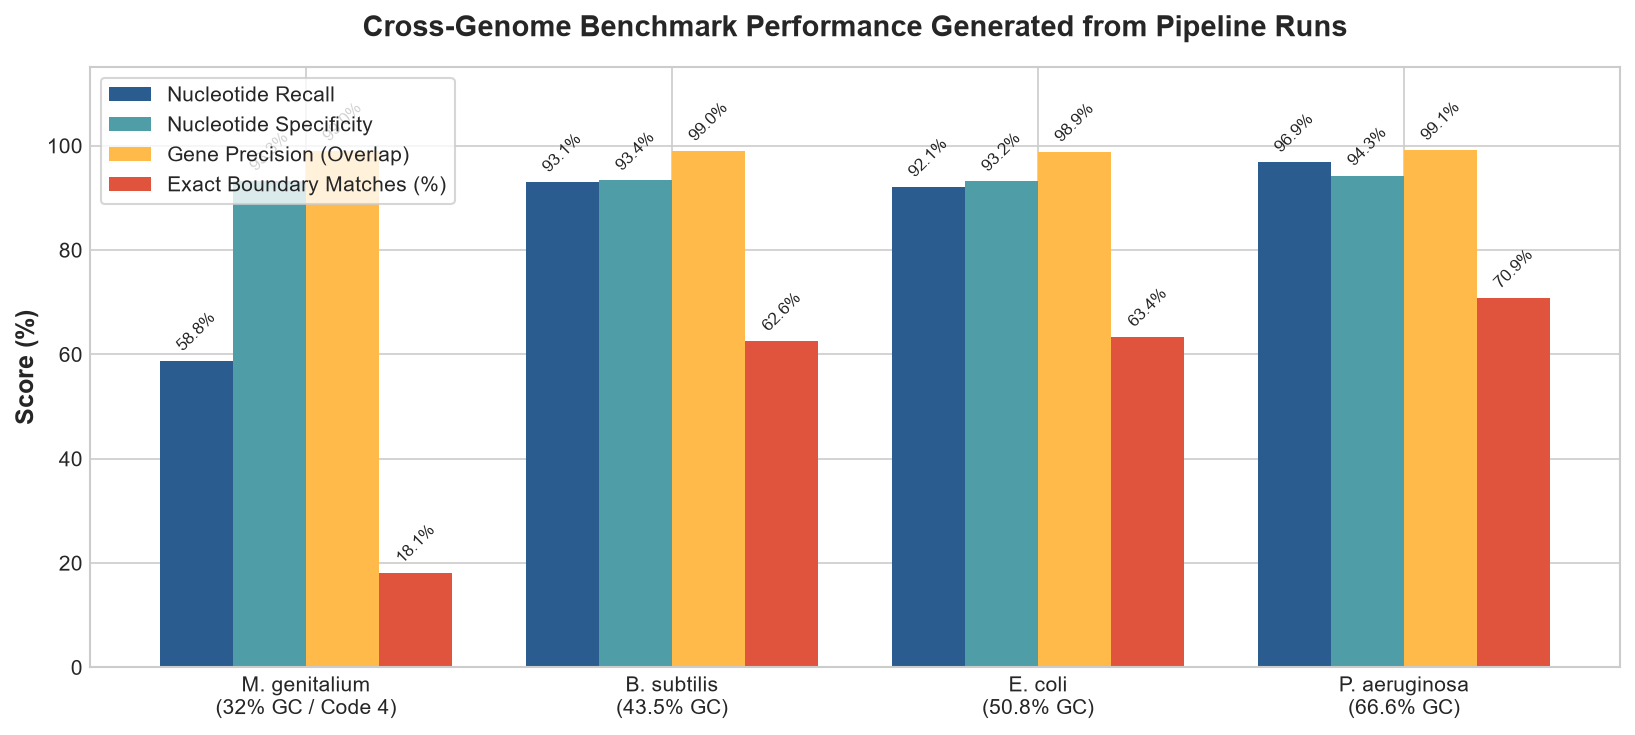

In [5]:
labels = [r["organism"] for r in benchmark_results]
recalls = [r["nuc_metrics"]["Nucleotide Sensitivity (Recall)"] for r in benchmark_results]
specificities = [r["nuc_metrics"]["Nucleotide Specificity"] for r in benchmark_results]
precisions = [r["gene_metrics"]["Gene Precision (Overlap)"] for r in benchmark_results]
exact_pcts = [
    (r["gene_metrics"]["Exact Boundary Matches (Start & Stop)"] / r["gene_metrics"]["Annotated Genes in Test Set"]) * 100
    for r in benchmark_results
]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5), dpi=fig_dpi)

r1 = ax.bar(x - 1.5*width, recalls, width, label='Nucleotide Recall', color='#2b5c8f')
r2 = ax.bar(x - 0.5*width, specificities, width, label='Nucleotide Specificity', color='#4f9da6')
r3 = ax.bar(x + 0.5*width, precisions, width, label='Gene Precision (Overlap)', color='#ffba49')
r4 = ax.bar(x + 1.5*width, exact_pcts, width, label='Exact Boundary Matches (%)', color='#e0533c')

ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Cross-Genome Benchmark Performance Generated from Pipeline Runs', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 115)
ax.legend(frameon=True, facecolor='white', loc='upper left')

for rects in [r1, r2, r3, r4]:
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

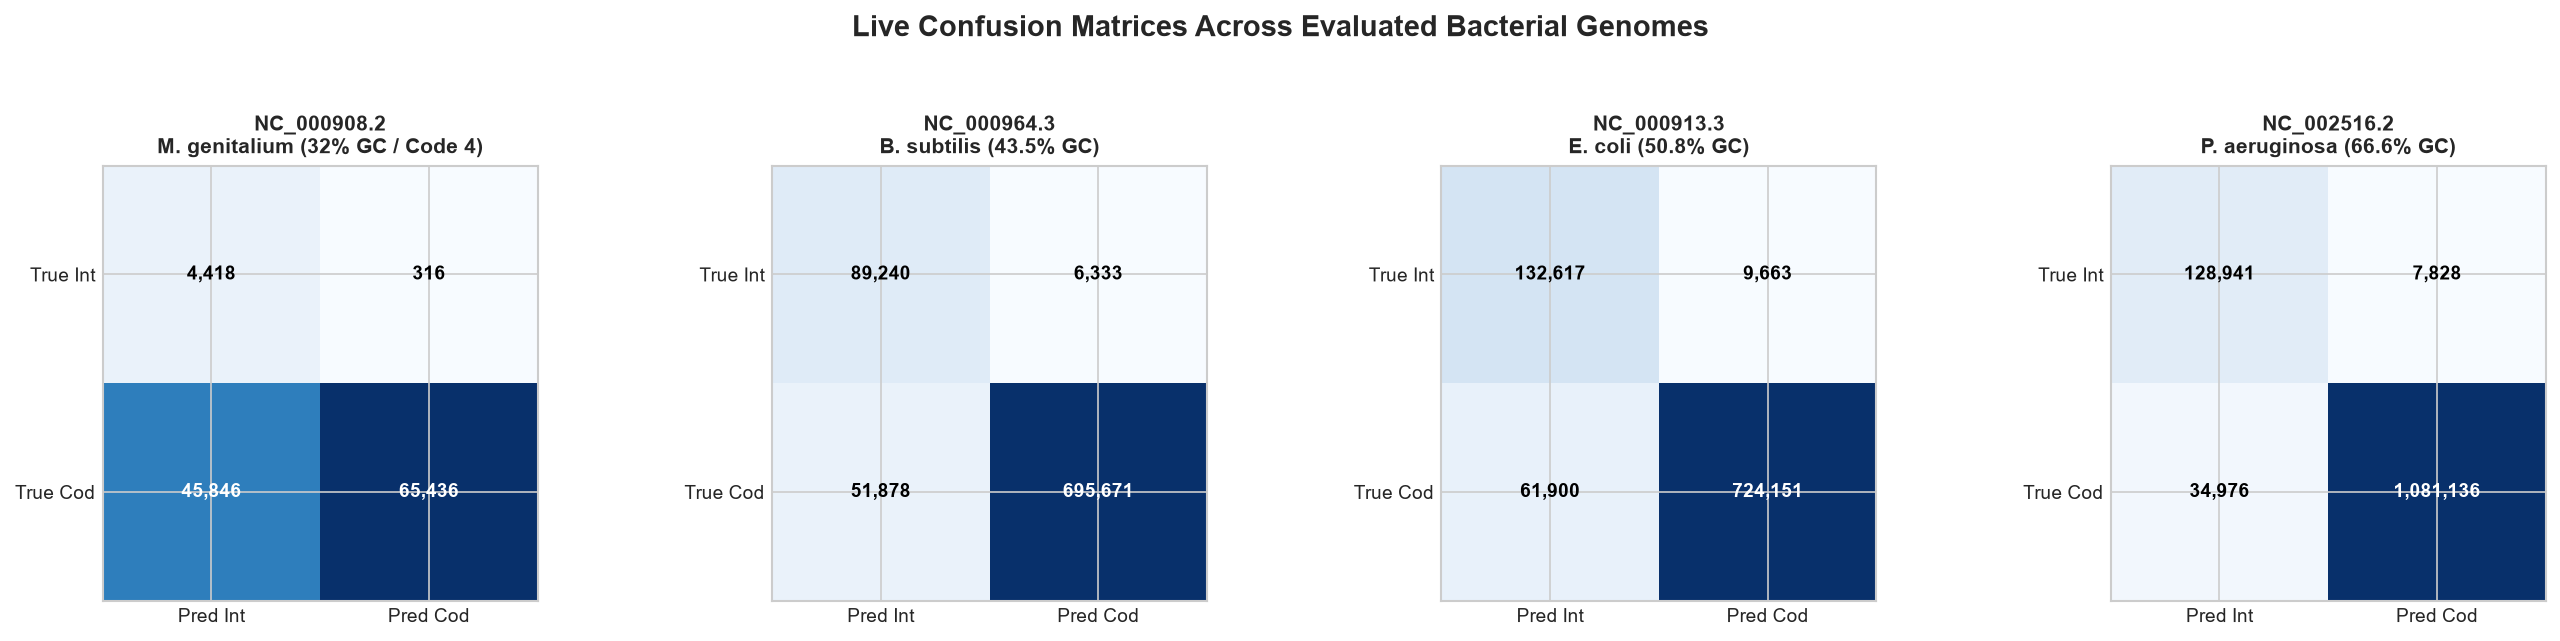

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), dpi=fig_dpi)

for idx, res in enumerate(benchmark_results):
    cm_dict = res["nuc_metrics"]["Confusion Matrix"]
    cm = np.array([
        [cm_dict["TN"], cm_dict["FP"]],
        [cm_dict["FN"], cm_dict["TP"]]
    ])
    
    ax = axes[idx]
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    ax.set_title(f"{res['accession']}\n{res['organism'].replace(chr(10), ' ')}", fontweight='bold', fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Int", "Pred Cod"], fontsize=9)
    ax.set_yticklabels(["True Int", "True Cod"], fontsize=9)
    
    threshold = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                     color="white" if cm[i, j] > threshold else "black", fontweight='bold', fontsize=9)

plt.suptitle("Live Confusion Matrices Across Evaluated Bacterial Genomes", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

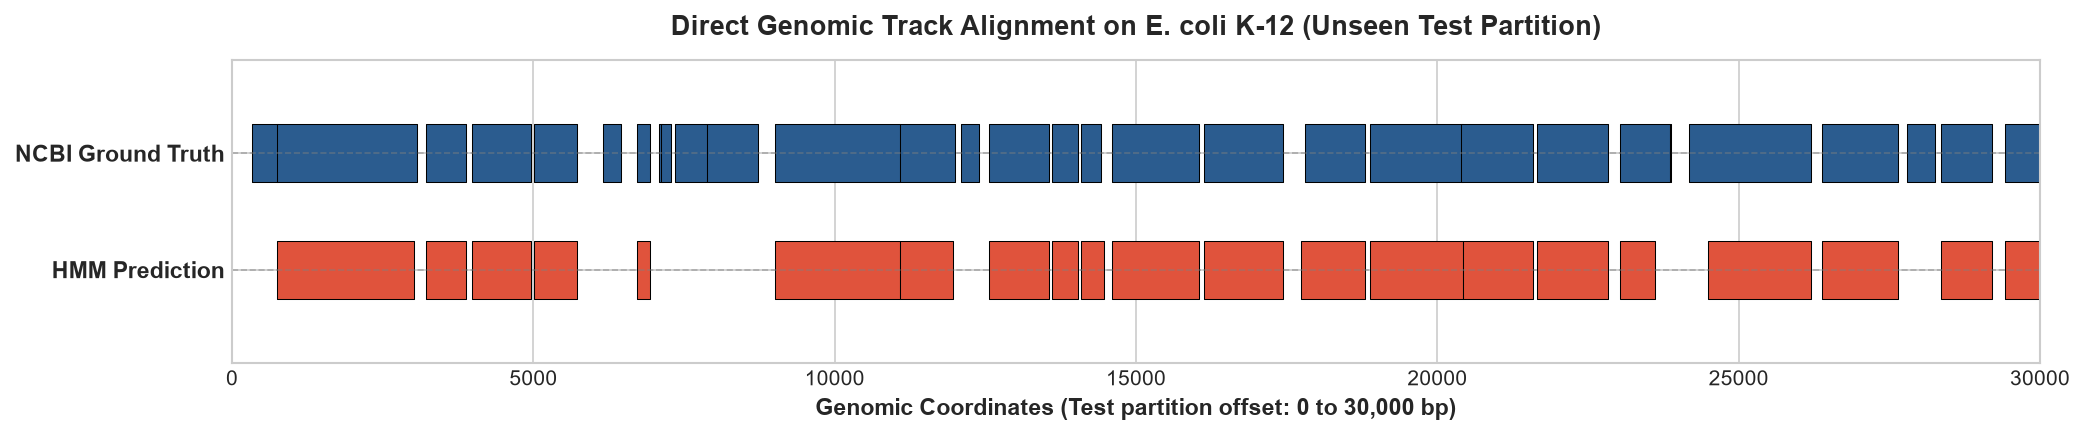

In [7]:
# Visualize the first 30,000 base pairs of the E. coli test partition
ecoli_res = next(r for r in benchmark_results if "NC_000913.3" in r["accession"])

window_start = 0
window_end = 30000

fig, ax = plt.subplots(figsize=(14, 3), dpi=fig_dpi)

# Ground Truth Track (y = 2)
ax.axhline(2, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
for s, e in ecoli_res["all_test_cds"]:
    if e >= window_start and s <= window_end:
        start_clip = max(s, window_start)
        end_clip = min(e, window_end)
        ax.broken_barh([(start_clip, end_clip - start_clip)], (1.75, 0.5), facecolors='#2b5c8f', edgecolor='black', linewidth=0.5)

# Predicted Track (y = 1)
ax.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
for s, e, *_ in ecoli_res["combined_genes"]:
    if e >= window_start and s <= window_end:
        start_clip = max(s, window_start)
        end_clip = min(e, window_end)
        ax.broken_barh([(start_clip, end_clip - start_clip)], (0.75, 0.5), facecolors='#e0533c', edgecolor='black', linewidth=0.5)

ax.set_ylim(0.2, 2.8)
ax.set_xlim(window_start, window_end)
ax.set_yticks([1, 2])
ax.set_yticklabels(['HMM Prediction', 'NCBI Ground Truth'], fontsize=11, fontweight='bold')
ax.set_xlabel(f'Genomic Coordinates (Test partition offset: {window_start:,} to {window_end:,} bp)', fontsize=11, fontweight='bold')
ax.set_title('Direct Genomic Track Alignment on E. coli K-12 (Unseen Test Partition)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()